In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/brjapon/cwru-bearing-datasets/CWRU_48k_load_1_CNN_data.npz
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/feature_time_48k_2048_load_1.csv
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR014_1_175.mat


In [17]:
import numpy as np
import pandas as pd
import os
import glob
from tqdm.notebook import tqdm
from scipy.io import loadmat

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.utils import to_categorical

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU available: []


2026-03-20 17:06:53.069142: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
DATA_DIR = "/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/"

In [4]:
#list all raw files in the dataset
import os
for dirname, _, filenames in os.walk(DATA_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR021_1_214.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B014_1_190.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR007_6_1_136.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR014_6_1_202.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B007_1_123.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR007_1_110.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/B021_1_227.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/Time_Normal_1_098.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/OR021_6_1_239.mat
/kaggle/input/datasets/brjapon/cwru-bearing-datasets/raw/IR014_1_175.mat


In [11]:
#configure hyperparameters

FS = 48000   # Sampling frequency (Hz)
WINDOW_SIZE      = 1024            # samples per segment
OVERLAP     = WINDOW // 2              # step size = WINDOW - OVERLAP (50 % overlap)
N_CLASSES   = 10
BATCH_SIZE  = 64
EPOCHS      = 20
LEARNING_RATE = 1e-3

In [9]:
#find keys of DE_time in the .mat files

def find_de_key(mat_dict: dict) -> str:
    """
    The drive-end key name differs slightly between files, e.g.:
        'X097_DE_time', 'X122_DE_time', 'DE_time' ...
    We locate it by checking for 'DE_time' anywhere in the key name.
    """
    for key in mat_dict:
        if "DE_time" in key and not key.startswith("__"):
            return key
    raise KeyError(f"No DE_time key found. Available keys: {list(mat_dict.keys())}")

In [10]:
def extract_cwru_signal(mat_content):
    for keys in mat_content.keys():
        if keys.startswith('__'):
            continue
        try:
            key = find_de_key(mat_content)
            data = mat_content[key]
            return  np.array(data).flatten().astype(np.float32)
        except:
            print(f"Error loading {mat_content} file")
    return None
            

In [12]:
#file map 
FILE_MAP = {
    "Time_Normal": (0, "Normal"),
    "B007":        (1, "Ball-007"),
    "B014":        (2, "Ball-014"),
    "B021":        (3, "Ball-021"),
    "IR007":       (4, "IR-007"),
    "IR014":       (5, "IR-014"),
    "IR021":       (6, "IR-021"),
    "OR007":       (7, "OR-007"),
    "OR014":       (8, "OR-014"),
    "OR021":       (9, "OR-021"),
}

In [21]:
def load_cwru_dataset(basePath, files_num=10):
    all_signals = []
    all_labels = []

    files = sorted(glob.glob(os.path.join(basePath, "*.mat")))
    print(f"Loaded {len(files)} files")  #must be 10

    for file_path in files[:files_num]:
        try:
            mat_data = loadmat(file_path)
            signals = extract_cwru_signal(mat_data)
            
            
        except  Exception as e:
            print(f"{e}")

    return pd.DataFrame({'signal': all_signals, 'label': all_labels})

print("Starting data load...")
df = load_cwru_dataset(DATA_DIR)

print(f"\nTotal files loaded : {len(df)}")
print(f"Classes found      : {sorted(df['label'].unique())}")
print(f"Samples per class  :\n{df['label'].value_counts().sort_index()}")

Starting data load...
Loaded 10 files


ValueError: All arrays must be of the same length

In [23]:
def load_cwru_dataset(basePath, files_num=10):
    all_signals = []
    all_labels = []

    files = sorted(glob.glob(os.path.join(basePath, "*.mat")))
    print(f"Loaded {len(files)} files")

    for file_path in files[:files_num]:
        try:
            mat_data = loadmat(file_path)
            signals = extract_cwru_signal(mat_data)

            if signals is not None and len(signals) > WINDOW_SIZE:
                file_name = os.path.basename(file_path)

                label_assigned = False

                for prefix, (label_id, label_name) in FILE_MAP.items():
                    if prefix in file_name:   # ✅ FIX
                        all_signals.append(signals)
                        all_labels.append(label_name)
                        label_assigned = True
                        break

                if not label_assigned:
                    print(f"No label found for {file_name}")

        except Exception as e:
            print(f"{e}")

    print(len(all_signals), len(all_labels))  # debug
    return pd.DataFrame({'signal': all_signals, 'label': all_labels})

print("Starting data load...")
df = load_cwru_dataset(DATA_DIR)

print(f"\nTotal files loaded : {len(df)}")
print(f"Classes found      : {sorted(df['label'].unique())}")
print(f"Samples per class  :\n{df['label'].value_counts().sort_index()}")

Starting data load...
Loaded 10 files
10 10

Total files loaded : 10
Classes found      : ['Ball-007', 'Ball-014', 'Ball-021', 'IR-007', 'IR-014', 'IR-021', 'Normal', 'OR-007', 'OR-014', 'OR-021']
Samples per class  :
label
Ball-007    1
Ball-014    1
Ball-021    1
IR-007      1
IR-014      1
IR-021      1
Normal      1
OR-007      1
OR-014      1
OR-021      1
Name: count, dtype: int64


In [6]:
#file map 
FILE_MAP = {
    "Time_Normal": (0, "Normal"),
    "B007":        (1, "Ball-007"),
    "B014":        (2, "Ball-014"),
    "B021":        (3, "Ball-021"),
    "IR007":       (4, "IR-007"),
    "IR014":       (5, "IR-014"),
    "IR021":       (6, "IR-021"),
    "OR007":       (7, "OR-007"),
    "OR014":       (8, "OR-014"),
    "OR021":       (9, "OR-021"),
}

In [9]:
CLASS_NAMES = [v[1] for v in sorted(FILE_MAP.values(), key=lambda x: x[0])]
#eg: FILE_MAP["B007"] -> (1, "Ball-007") means label 1 corresponds to "Ball-007" class.

In [10]:
#find keys of DE_time in the .mat files

def find_de_key(mat_dict: dict) -> str:
    """
    The drive-end key name differs slightly between files, e.g.:
        'X097_DE_time', 'X122_DE_time', 'DE_time' ...
    We locate it by checking for 'DE_time' anywhere in the key name.
    """
    for key in mat_dict:
        if "DE_time" in key and not key.startswith("__"):
            return key
    raise KeyError(f"No DE_time key found. Available keys: {list(mat_dict.keys())}")

In [11]:
#load the .mat files
def load_cwru_dataset(data_dir: str) -> tuple[dict, dict]:
    """
    Scans data_dir for .mat files, matches each file to its class label
    via FILE_MAP, and returns two dicts:
        raw_signals  : { label_int : 1D np.ndarray }
        label_names  : { label_int : class_name_str }
    """
    raw_signals = {}
    label_names = {}
 
    mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]
    if not mat_files:
        raise FileNotFoundError(f"No .mat files found in '{data_dir}'")
 
    print(f"\n{'='*60}")
    print("STEP 1 — Loading raw signals")
    print(f"{'='*60}")
 
    for filename in sorted(mat_files):
        filepath = os.path.join(data_dir, filename)
 
        # Match filename prefix to FILE_MAP
        matched_label = None
        matched_name  = None
        for prefix, (label_id, label_name) in FILE_MAP.items():
            if filename.startswith(prefix):
                matched_label = label_id
                matched_name  = label_name
                break
 
        if matched_label is None:
            print(f"  [SKIP] {filename} — not in FILE_MAP")
            continue
 
        mat = scipy.io.loadmat(filepath)
        de_key = find_de_key(mat)
        signal = mat[de_key].squeeze().astype(np.float64)
 
        raw_signals[matched_label] = signal
        label_names[matched_label] = matched_name
 
        print(f"  [OK]   {filename:<35} → class {matched_label:02d} "
              f"'{matched_name}'   samples={len(signal):,}")
 
    print(f"\n  Loaded {len(raw_signals)} / {N_CLASSES} classes.\n")
    return raw_signals, label_names



STEP 1 — Loading raw signals
  [OK]   B007_1_123.mat                      → class 01 'Ball-007'   samples=487,384
  [OK]   B014_1_190.mat                      → class 02 'Ball-014'   samples=486,224
  [OK]   B021_1_227.mat                      → class 03 'Ball-021'   samples=486,804
  [OK]   IR007_1_110.mat                     → class 04 'IR-007'   samples=486,224
  [OK]   IR014_1_175.mat                     → class 05 'IR-014'   samples=489,125
  [OK]   IR021_1_214.mat                     → class 06 'IR-021'   samples=485,063
  [OK]   OR007_6_1_136.mat                   → class 07 'OR-007'   samples=486,804
  [OK]   OR014_6_1_202.mat                   → class 08 'OR-014'   samples=484,483
  [OK]   OR021_6_1_239.mat                   → class 09 'OR-021'   samples=489,125
  [OK]   Time_Normal_1_098.mat               → class 00 'Normal'   samples=483,903

  Loaded 10 / 10 classes.

Analyzing signal: Ball-007 (length: 487384 samples)


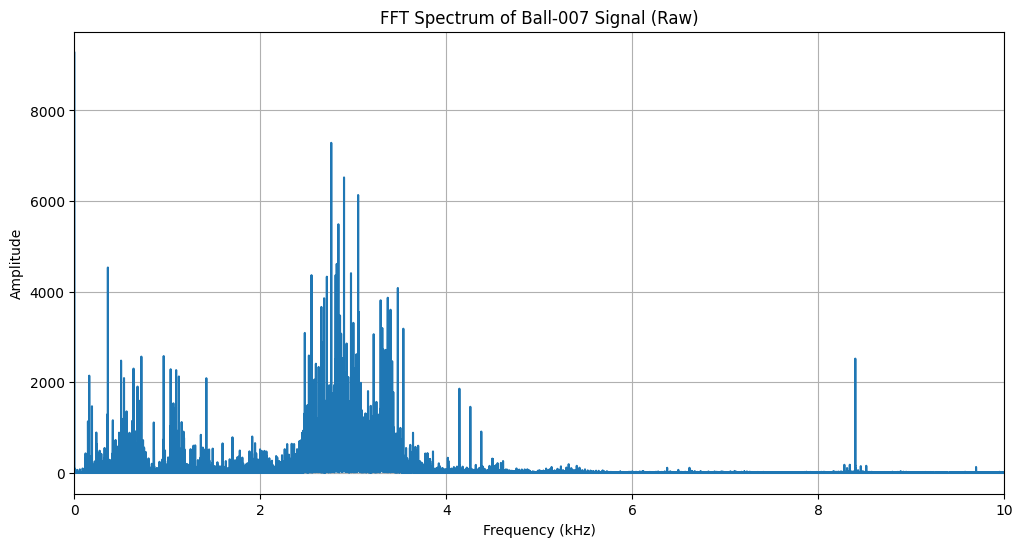

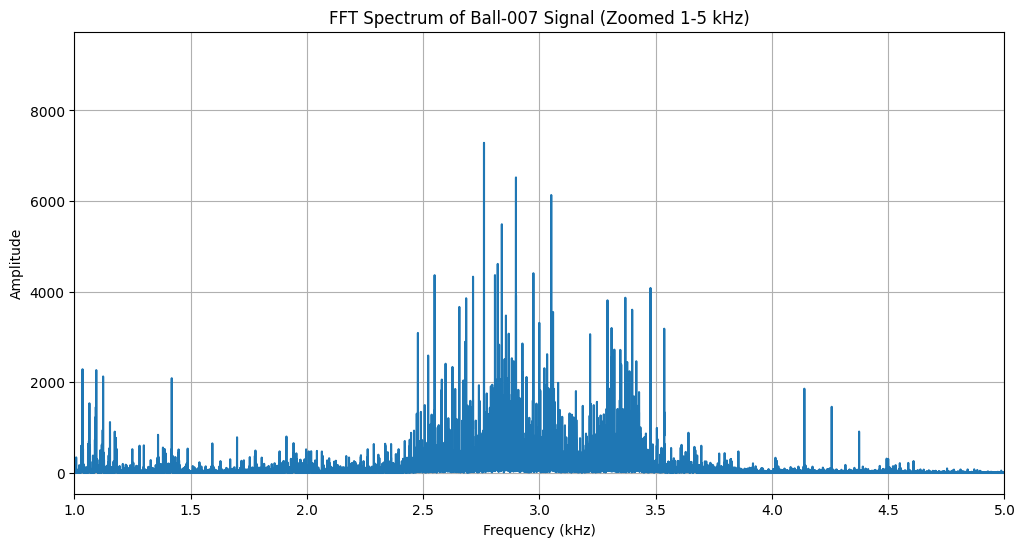

In [12]:
# Load a sample signal and plot its FFT to analyze frequency spectrum
import matplotlib.pyplot as plt

# Load raw signals (assuming load_cwru_dataset is already run or run it here)
raw_signals, label_names = load_cwru_dataset(DATA_DIR)

# Pick a sample signal (e.g., the first one, 'Normal')
sample_key = list(raw_signals.keys())[0]  # e.g., 0 for 'Normal'
sample_signal = raw_signals[sample_key]
sample_label = label_names[sample_key]

print(f"Analyzing signal: {sample_label} (length: {len(sample_signal)} samples)")

# Compute FFT
from scipy.fft import fft, fftfreq
import numpy as np

# Sampling frequency
fs = FS  # 48000 Hz from hyperparameters

# FFT
N = len(sample_signal)
yf = fft(sample_signal)
xf = fftfreq(N, 1/fs)

# Only positive frequencies
xf_pos = xf[:N//2]
yf_pos = np.abs(yf[:N//2])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(xf_pos / 1000, yf_pos)  # Convert to kHz
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude')
plt.title(f'FFT Spectrum of {sample_label} Signal (Raw)')
plt.xlim(0, 10)  # Focus on 0-10 kHz
plt.grid(True)
plt.show()

# Optional: Zoom in on 1-5 kHz
plt.figure(figsize=(12, 6))
plt.plot(xf_pos / 1000, yf_pos)
plt.xlabel('Frequency (kHz)')
plt.ylabel('Amplitude')
plt.title(f'FFT Spectrum of {sample_label} Signal (Zoomed 1-5 kHz)')
plt.xlim(1, 5) # Focus on 1-5 kHz
plt.grid(True)
plt.show()

In [13]:
def bandpass_filter(signal: np.ndarray,
                    fs: int,
                    low_hz: float = 100.0,
                    high_hz: float = 5500.0,
                    order: int = 4) -> np.ndarray:
    """
    4th-order Butterworth bandpass filter.
    Removes: DC / low-freq drift (< 100 Anti-aliasing / noise above 5500 Hz  (Nyquist = 24000 Hz @ 48 kHz)
    """
    nyq = fs / 2.0
    low  = low_hz  / nyq
    high = high_hz / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

In [14]:
def preprocess_signal(signal: np.ndarray,
                      fs: int = FS,
                      apply_filter: bool = False) -> np.ndarray:
    """
    Full per-signal preprocessing chain:
      1. Remove DC offset   (subtract mean)
      2. Bandpass filter    (100 – 5500 Hz)    [optional but recommended]
      3. Z-score normalise  (zero mean, unit variance)
 
    Why z-score and NOT min-max?
      Min-max is sensitive to outlier spikes (very common in vibration).
      Z-score is stable and generalises across different load conditions.
    """
    # 1. DC removal
    signal = signal - np.mean(signal)
 
    # 2. Bandpass filter
    if apply_filter:
        signal = bandpass_filter(signal, fs)
 
    # 3. Z-score normalisation
    std = signal.std() + 1e-10  # add small epsilon to prevent division by zero
    signal = signal / std               # mean already ~0 after step 1
 
    return signal


In [15]:
def preprocess_all(raw_signals: dict, fs: int = FS,
                   apply_filter: bool = True) -> dict:
    """Apply preprocessing to every class signal."""
    print(f"{'='*60}")
    print("STEP 2 — Preprocessing signals")
    print(f"{'='*60}")
 
    processed = {}
    for label, signal in raw_signals.items():
        processed[label] = preprocess_signal(signal, fs, apply_filter)
        print(f"  Class {label:02d}  —  DC removed, filtered, z-scored  "
              f"(μ={processed[label].mean():.4f}, σ={processed[label].std():.4f})")
    print()
    return processed

In [16]:
def augment_segment(x: np.ndarray,
                    noise_std:    float = 0.01,
                    scale_range:  tuple = (0.9, 1.1),
                    max_shift:    int   = 50) -> np.ndarray:
    """
    Three lightweight augmentations for 1D vibration signals:
 
    1. Gaussian noise   — simulates sensor noise variations
    2. Amplitude jitter — simulates different load/speed conditions
    3. Circular time shift — simulates random trigger phase
 
    All are physics-realistic: they change the signal the way real-world
    measurement conditions would, without altering the fault class.
    """
    # 1. additive Gaussian noise
    noise = np.random.normal(0.0, noise_std, x.shape).astype(np.float32)
    # 2. random amplitude scaling
    scale = np.random.uniform(*scale_range)
    # 3. random circular shift  (circular = no edge artefacts)
    shift = np.random.randint(-max_shift, max_shift)
    x_aug = np.roll(x * scale + noise, shift, axis=0)
    return x_aug.astype(np.float32)